This file is to essentially check the data within the new physics dataset, generated by Ahbay

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
fizz_dataset = pd.read_csv("../data/processed/physics_modelled_2022_2025.csv")

First, check the number of races per year

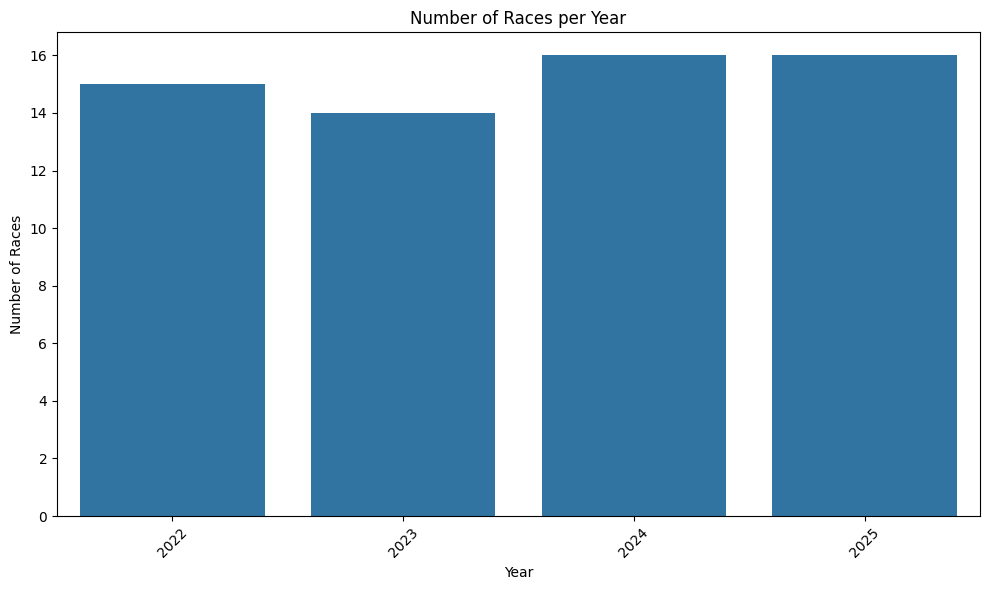

In [7]:
gr_races_year = fizz_dataset.groupby("Season")["RaceID"].nunique().reset_index(name="num_races")
plt.figure(figsize=(10, 6))
sns.barplot(x="Season", y="num_races", data=gr_races_year)
plt.title("Number of Races per Year")
plt.xlabel("Year")
plt.ylabel("Number of Races")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Then, check the number of drivers in each race (plot as a distribution of sorts)

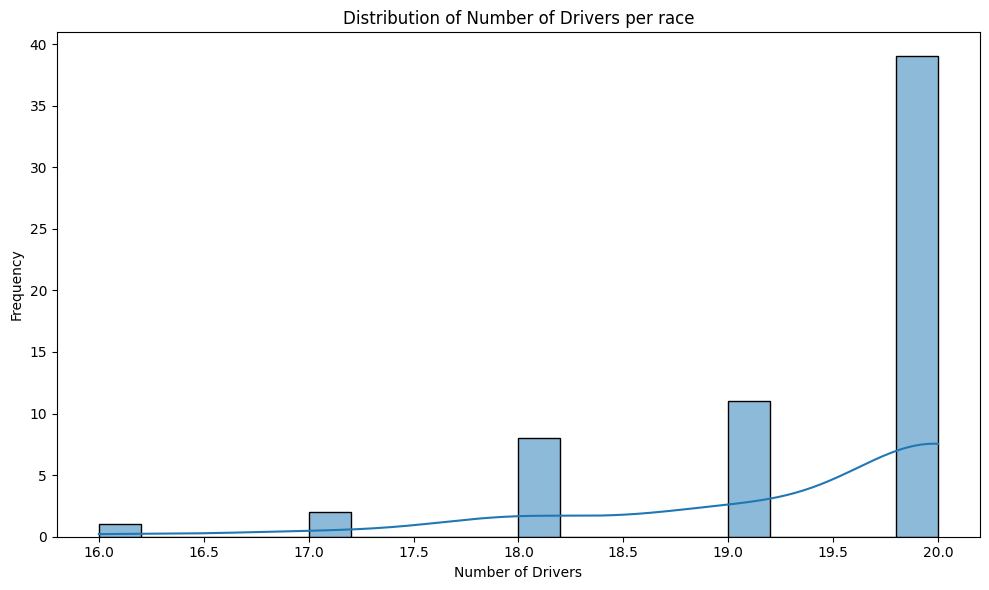

In [10]:
# group by races, get the number of unique drivers per race
gr_races = fizz_dataset.groupby("RaceID")["Driver"].nunique().reset_index(name="num_drivers")
# plot distribution of number of drivers
plt.figure(figsize=(10, 6))
sns.histplot(gr_races["num_drivers"], bins=20, kde=True)
plt.title("Distribution of Number of Drivers per race")
plt.xlabel("Number of Drivers")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

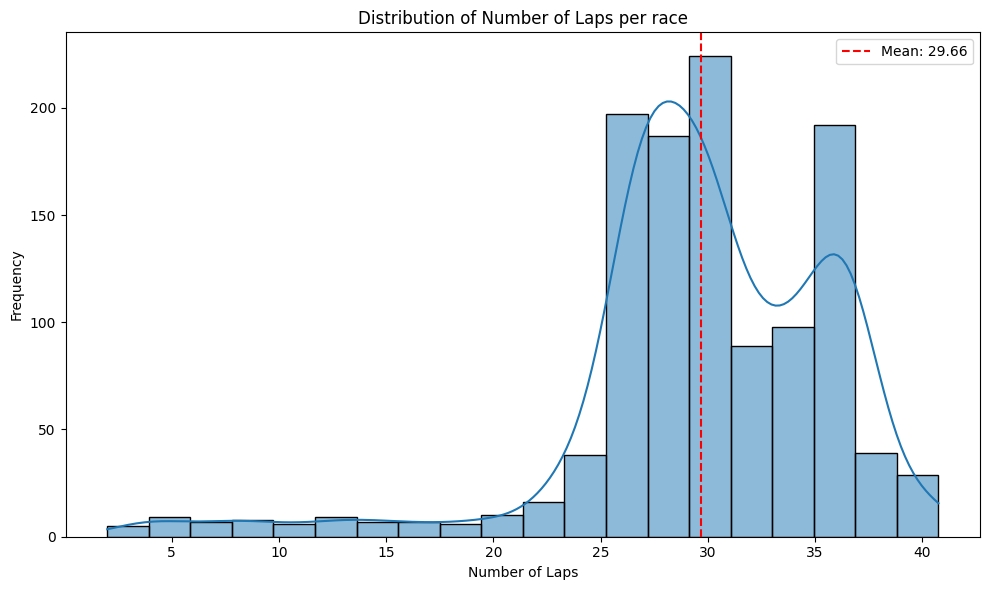

In [18]:
# next plot the distribution of the mean number of laps per driver race
gr_laps = fizz_dataset.groupby(["RaceID", "Driver"])["LapNumber"].mean().reset_index(name="LapNumber")
# plot the mean number of laps per driver as a scalar value

gr_laps_mean =gr_laps["LapNumber"].mean()
plt.figure(figsize=(10, 6))
sns.histplot(gr_laps["LapNumber"], bins=20, kde=True)
plt.axvline(gr_laps_mean, color='red', linestyle='--', label=f'Mean: {gr_laps_mean:.2f}')
plt.legend()
plt.title("Distribution of Number of Laps per race")
plt.xlabel("Number of Laps")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Now to check the physics attributes

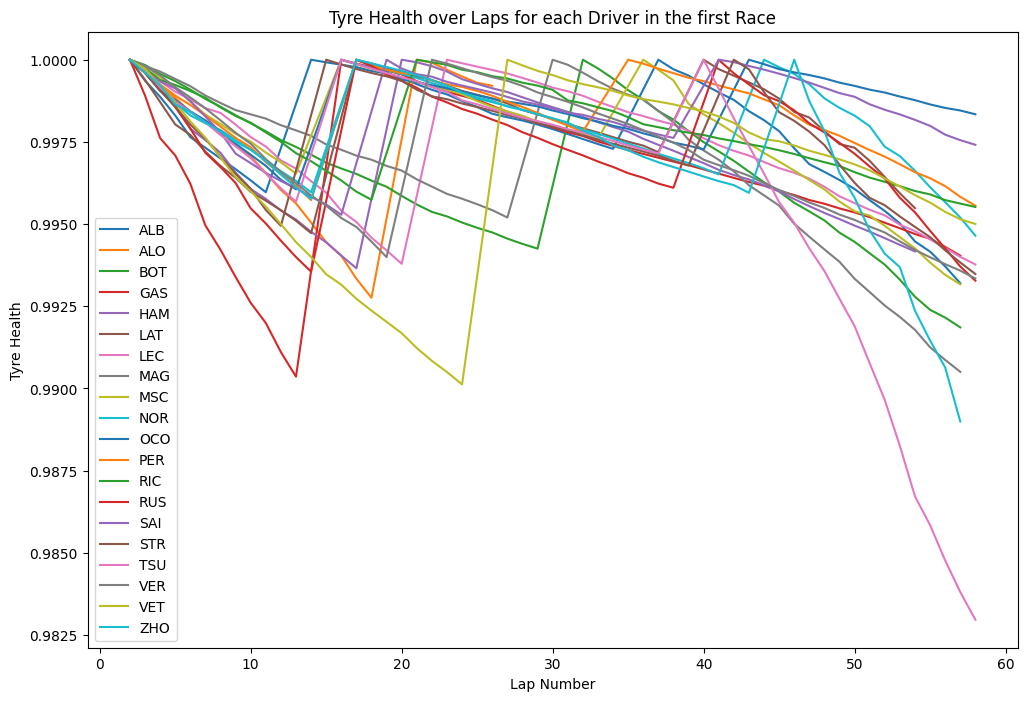

In [19]:
# for the first race in the dataset, plot the tyre health over the laps for each driver
first_race_df = fizz_dataset[fizz_dataset["RaceID"] == fizz_dataset["RaceID"].unique()[0]]
driver_groups = first_race_df.groupby("Driver")
plt.figure(figsize=(12, 8))
for driver, group in driver_groups:
    plt.plot(group["LapNumber"], group["TyreHealth"], label=driver)
plt.title("Tyre Health over Laps for each Driver in the first Race")
plt.xlabel("Lap Number")
plt.ylabel("Tyre Health")
plt.legend()
plt.show()

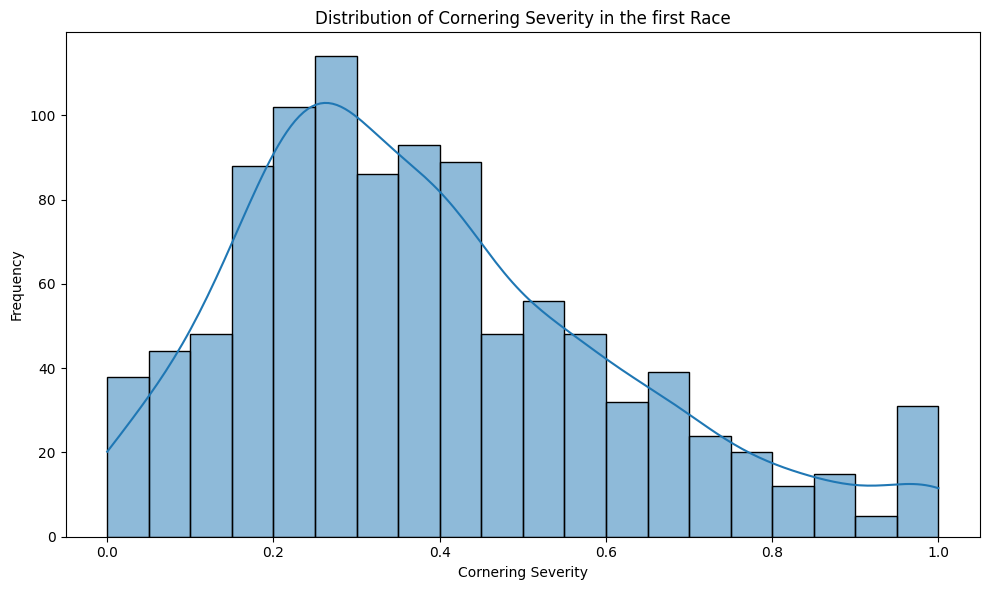

In [20]:
# now plot the distribution of cornering severiy for the same dataset
plt.figure(figsize=(10, 6))
sns.histplot(first_race_df["CorneringSeverity"], bins=20, kde=True)
plt.title("Distribution of Cornering Severity in the first Race")
plt.xlabel("Cornering Severity")
plt.ylabel("Frequency")
plt.tight_layout()

In [34]:
# now to test the correlation between tyre health and various statistics.
# to do this, we will group the dataset by race and driver, compute the difference in tyre health for each driver.
working_df = fizz_dataset.copy()
working_df.groupby(["RaceID", "Driver"])["TyreHealth"]
# sort by lapNumber just to be sure
working_df = working_df.sort_values(by=["RaceID", "Driver", "LapNumber"])
working_df["TyreHealthDiff"] = working_df.groupby(["RaceID", "Driver"])["TyreHealth"].diff()
# remove all cases where diff was positive; that is where a tyre change took place
working_df = working_df.fillna(0) # ie no change in tyre health for the first lap
working_df = working_df[working_df["TyreHealthDiff"] <= 0]

working_df["TyreHealthDiff"].head(10)

0    0.000000
1   -0.000636
2   -0.000493
3   -0.000566
4   -0.000658
5   -0.000326
6   -0.000323
7   -0.000326
8   -0.000342
9   -0.000361
Name: TyreHealthDiff, dtype: float64

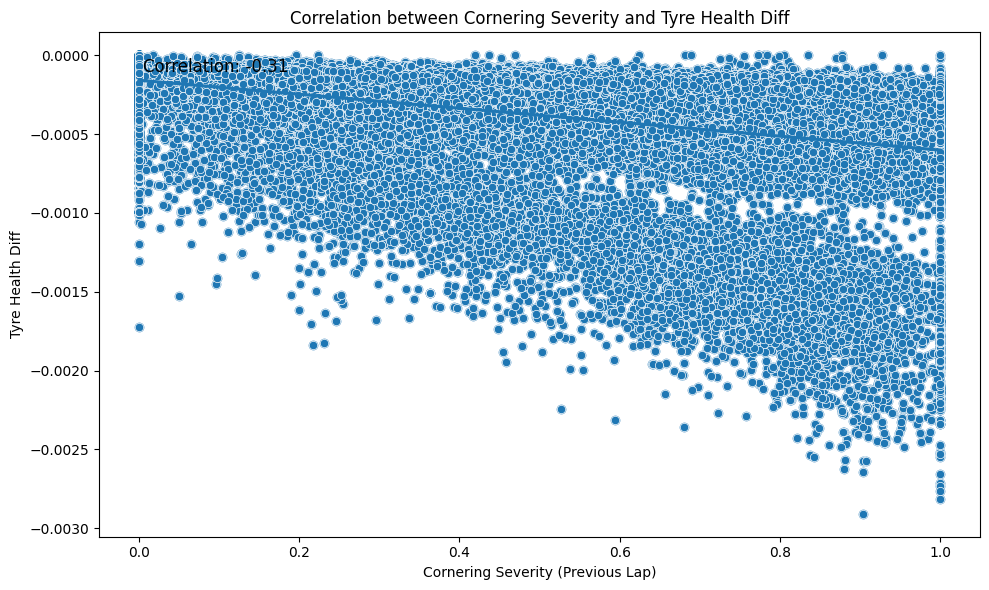

In [36]:
# plot the correlation between tyre health diff and cornering severity from the previous lap.
working_df["CorneringSeverityPrev"] = working_df.groupby(["RaceID", "Driver"])["CorneringSeverity"].shift(1)
plt.figure(figsize=(10, 6))
# add a regression line to the scatter plot
sns.regplot(x="CorneringSeverityPrev", y="TyreHealthDiff", data=working_df)
# add a correlation coefficient to the plot
corr = working_df[["CorneringSeverityPrev", "TyreHealthDiff"]].corr().iloc[0, 1]
plt.text(0.05, 0.95, f'Correlation: {corr:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
sns.scatterplot(x="CorneringSeverityPrev", y="TyreHealthDiff", data=working_df)
plt.title("Correlation between Cornering Severity and Tyre Health Diff")
plt.xlabel("Cornering Severity (Previous Lap)")
plt.ylabel("Tyre Health Diff")
plt.tight_layout()
plt.show()

/var/folders/63/__1p4tt55zq_byscd0qttqcc0000gn/T/ipykernel_3737/383603273.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  working_df["LapTimeDiff"] = working_df.groupby(["RaceID", "Driver"])["LapTime_s"].diff()


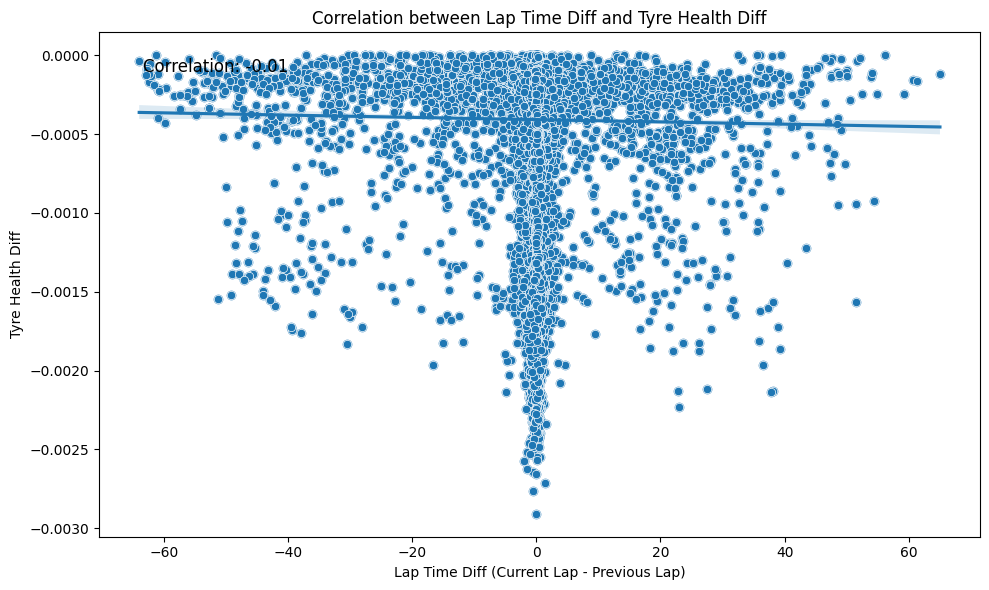

In [41]:
# plot the correlation between tyre health and the increase in lap time wrt the previous lap
working_df["LapTimeDiff"] = working_df.groupby(["RaceID", "Driver"])["LapTime_s"].diff()

plt.figure(figsize=(10, 6))
# add a regression line to the scatter plot
sns.regplot(x="LapTimeDiff", y="TyreHealthDiff", data=working_df)
# add a correlation coefficient to the plot
corr = working_df[["LapTimeDiff", "TyreHealthDiff"]].corr().iloc[0, 1]
plt.text(0.05, 0.95, f'Correlation: {corr:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
sns.scatterplot(x="LapTimeDiff", y="TyreHealthDiff", data=working_df)
plt.title("Correlation between Lap Time Diff and Tyre Health Diff")
plt.xlabel("Lap Time Diff (Current Lap - Previous Lap)")
plt.ylabel("Tyre Health Diff")
plt.tight_layout()
plt.show()

Above plot shows that there is too much noise to see for sure the effect of tyre health change on lap time.